# Inference Debugging

In [1]:
import sys
from pathlib import Path

# resolve project root (music-gen/) regardless of where the notebook is run from
PROJECT_ROOT = Path("../../../../").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from midi_gen.data_management.testing import get_seed_tokens
from midi_gen.model.models.GPTMidiV1 import GPTMidiV1
from midi_gen.model.inference.base_inference import create_sample_tokens
from midi_gen.data_management.tokenizing import create_vocabulary, reconstruct_notes

MODEL_PATH = PROJECT_ROOT / "src/midi_gen/model/models/midiv1_best.pt"
DATASET_PATH = PROJECT_ROOT / "data/tokenized_dataset.npy"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = GPTMidiV1()
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.to(device)
model.eval()
print("Model loaded.")

Model loaded.


In [2]:
seed_np = get_seed_tokens(i=0, j=100, dataset_path=str(DATASET_PATH))
seed = torch.tensor(seed_np, dtype=torch.long).unsqueeze(0).to(device)

tokens = create_sample_tokens(model, max_length=1024, temperature=0.9, top_p=0.9, seed=seed)
token_indices = tokens[0].tolist()

_, inverse = create_vocabulary()
token_strings = [inverse[t] for t in token_indices]
notes, errors = reconstruct_notes(token_strings)

print(f"Generated {len(notes)} notes, {len(errors)} decode error(s)")

Row 0, first 100 tokens:
['<SOS>', '<TIME_SHIFT_156>', '<TIME_SHIFT_76>', '<VELOCITY_16>', '<ON_71>', '<TIME_SHIFT_77>', '<OFF_71>', '<TIME_SHIFT_75>', '<VELOCITY_12>', '<ON_55>', '<TIME_SHIFT_0>', '<VELOCITY_14>', '<ON_71>', '<TIME_SHIFT_98>', '<VELOCITY_14>', '<ON_59>', '<TIME_SHIFT_41>', '<OFF_55>', '<TIME_SHIFT_89>', '<OFF_59>', '<VELOCITY_14>', '<ON_62>', '<TIME_SHIFT_85>', '<OFF_62>', '<TIME_SHIFT_41>', '<VELOCITY_20>', '<ON_72>', '<TIME_SHIFT_0>', '<OFF_71>', '<TIME_SHIFT_0>', '<VELOCITY_15>', '<ON_67>', '<TIME_SHIFT_31>', '<OFF_72>', '<TIME_SHIFT_93>', '<VELOCITY_16>', '<ON_57>', '<VELOCITY_18>', '<ON_74>', '<TIME_SHIFT_17>', '<OFF_67>', '<TIME_SHIFT_45>', '<VELOCITY_20>', '<ON_72>', '<TIME_SHIFT_61>', '<OFF_74>', '<VELOCITY_13>', '<ON_74>', '<TIME_SHIFT_0>', '<OFF_72>', '<TIME_SHIFT_49>', '<VELOCITY_16>', '<ON_72>', '<TIME_SHIFT_28>', '<VELOCITY_15>', '<ON_67>', '<TIME_SHIFT_1>', '<OFF_74>', '<TIME_SHIFT_78>', '<OFF_67>', '<TIME_SHIFT_53>', '<VELOCITY_15>', '<ON_66>', '<TIME_S

In [7]:
from midi_gen.data_management.midi_io import write_midi
from midi_gen.exploration.midi_test import play_wav
import subprocess

MIDI_OUT     = str(PROJECT_ROOT / "data/midi/generated.midi")
WAV_OUT      = str(PROJECT_ROOT / "data/outputs/generated.wav")
SOUNDFONT    = str(PROJECT_ROOT / "data/GeneralUser-GS/GeneralUser-GS.sf2")

write_midi(notes, MIDI_OUT)

subprocess.run([
    'fluidsynth', '-ni', '-g', '1.0', '-F', WAV_OUT, SOUNDFONT, MIDI_OUT
], check=True)

play_wav(WAV_OUT)

FluidSynth runtime version 2.5.3
Copyright (C) 2000-2026 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/Users/ryanwilliams/Projects/music-gen/data/outputs/generated.wav'..


## Pitch Histogram

Checks whether the model is staying in the middle register (chordal texture) vs. using the full keyboard.
The soprano/melody range starts around C5 (MIDI 72). Classical piano typically spans MIDI 21–108.

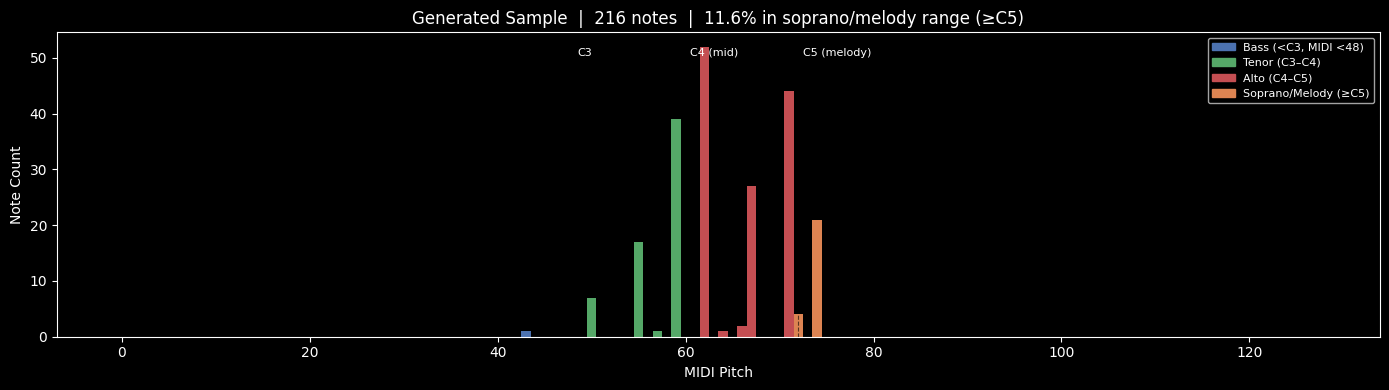

Pitch range: 43–74
Mean pitch:  64.3  (C4 = 60, C5 = 72)
Soprano/melody range (≥72): 11.6%


In [4]:
def pitch_histogram(notes, title="Pitch Histogram"):
    pitches = [n[2] for n in notes]  # (start, end, pitch, velocity)

    bass_cutoff   = 48   # C3
    tenor_cutoff  = 60   # C4
    alto_cutoff   = 72   # C5  — melody/soprano starts here
    soprano_top   = 96   # C7

    colors = []
    for p in range(128):
        if p < bass_cutoff:
            colors.append("#4C72B0")   # bass — blue
        elif p < tenor_cutoff:
            colors.append("#55A868")   # tenor — green
        elif p < alto_cutoff:
            colors.append("#C44E52")   # alto — red
        else:
            colors.append("#DD8452")   # soprano/melody — orange

    counts = np.bincount(pitches, minlength=128)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(128), counts, color=colors, width=1.0)

    for cutoff, label in [(bass_cutoff, "C3"), (tenor_cutoff, "C4 (mid)"), (alto_cutoff, "C5 (melody)")]:
        ax.axvline(cutoff, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(cutoff + 0.5, ax.get_ylim()[1] * 0.95, label, fontsize=8, va="top")

    legend = [
        mpatches.Patch(color="#4C72B0", label=f"Bass (<C3, MIDI <{bass_cutoff})"),
        mpatches.Patch(color="#55A868", label=f"Tenor (C3–C4)"),
        mpatches.Patch(color="#C44E52", label=f"Alto (C4–C5)"),
        mpatches.Patch(color="#DD8452", label=f"Soprano/Melody (≥C5)"),
    ]
    ax.legend(handles=legend, fontsize=8)

    total = len(pitches)
    soprano_pct = sum(1 for p in pitches if p >= alto_cutoff) / total * 100
    ax.set_title(f"{title}  |  {total} notes  |  {soprano_pct:.1f}% in soprano/melody range (≥C5)")
    ax.set_xlabel("MIDI Pitch")
    ax.set_ylabel("Note Count")
    plt.tight_layout()
    plt.show()

    print(f"Pitch range: {min(pitches)}–{max(pitches)}")
    print(f"Mean pitch:  {np.mean(pitches):.1f}  (C4 = 60, C5 = 72)")
    print(f"Soprano/melody range (≥72): {soprano_pct:.1f}%")


pitch_histogram(notes, title="Generated Sample")

### Compare against ground truth

Run the same histogram on a real dataset row to see what the target distribution looks like.

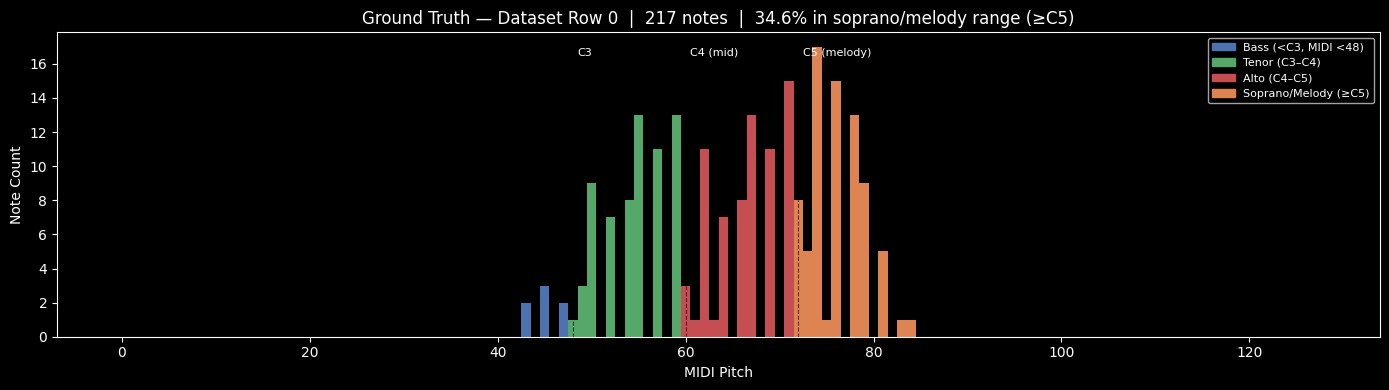

Pitch range: 43–84
Mean pitch:  65.6  (C4 = 60, C5 = 72)
Soprano/melody range (≥72): 34.6%


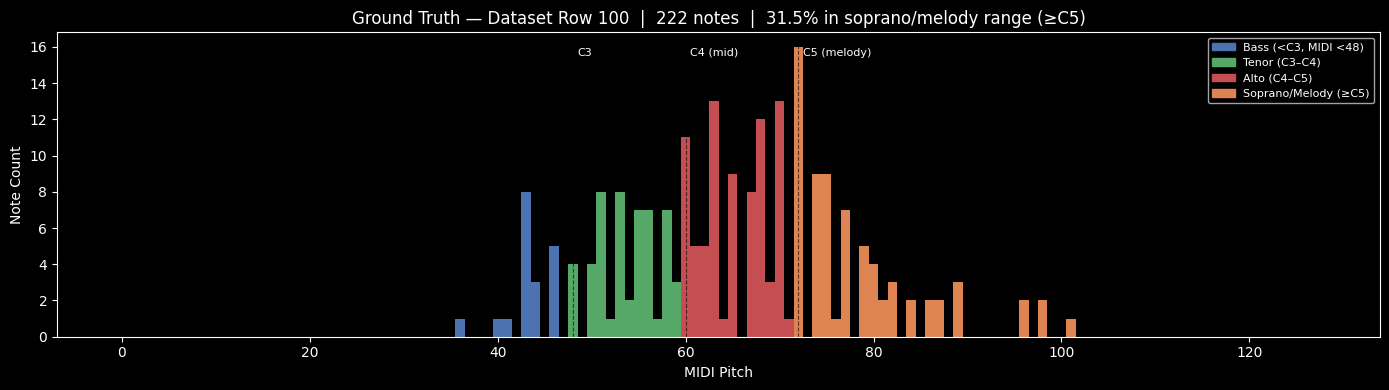

Pitch range: 36–101
Mean pitch:  64.9  (C4 = 60, C5 = 72)
Soprano/melody range (≥72): 31.5%


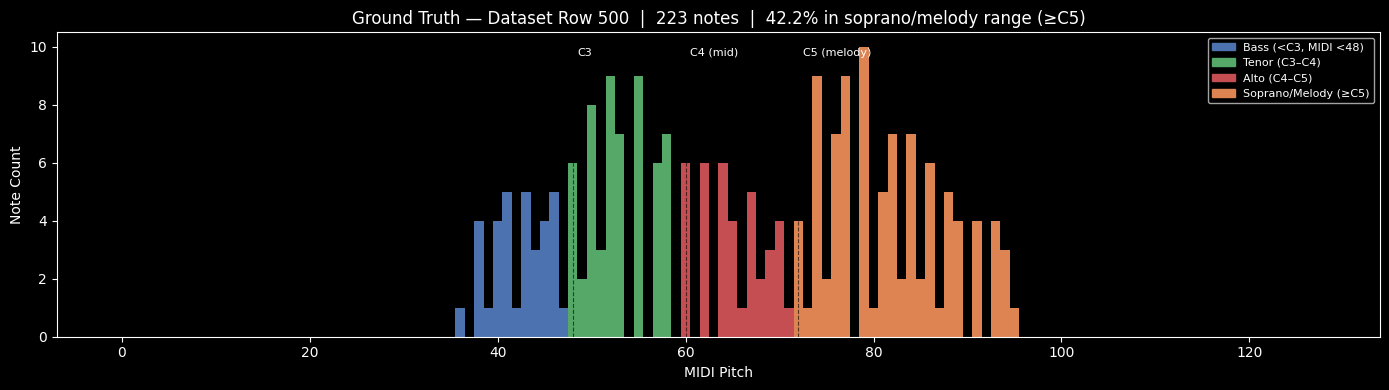

Pitch range: 36–95
Mean pitch:  65.5  (C4 = 60, C5 = 72)
Soprano/melody range (≥72): 42.2%


In [5]:
arr = np.load(str(DATASET_PATH), mmap_mode="r")
_, inverse = create_vocabulary()

ROWS = [0, 100, 500]
for row_idx in ROWS:
    row_tokens = arr[row_idx].tolist()
    token_strings = [inverse[t] for t in row_tokens]
    gt_notes, _ = reconstruct_notes(token_strings)
    if gt_notes:
        pitch_histogram(gt_notes, title=f"Ground Truth — Dataset Row {row_idx}")